# Using NOAA bathy from https://www.ncei.noaa.gov/maps/grid-extract/ for South Hood Canal and Lynch Cove

In [16]:
import cmocean.cm as cm 
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np

from salishsea_tools import bathy_tools, nc_tools, viz_tools

%matplotlib inline

import matplotlib.colors as matcolors
import matplotlib.cm as cmx

import rasterio
import xarray as xr
from scipy.interpolate import griddata
from pathlib import Path

In [17]:
# Plotting Set Up
cmap = cm.deep
cmap.set_bad('darkgreen')
ylim = (47, 48)
xlim = (-124, -122.2)
xlimLC = (-123.2, -122.83)
ylimLC = (47.33, 47.45)
cNorm  = matcolors.Normalize(vmin=0, vmax=14)
scalarMap = cmx.ScalarMappable(norm=cNorm, cmap='cool')

In [19]:
noaa_file = "NOAA_SouthHoodCanalLynchCove.tiff"
model_file = "/ocean/atall/MOAD/grid/bathymetry_202310b.nc"

xminLC, xmaxLC = -123.2, -122.83
yminLC, ymaxLC = 47.33, 47.45

MIN_DEPTH = 4

In [20]:
# Load NOAA Bathy (.tiff)
with rasterio.open(noaa_file) as src:
    elevation = src.read(1)
    transform = src.transform

rows, cols = elevation.shape
xs, ys = np.meshgrid(np.arange(cols), np.arange(rows))
lon_obs, lat_obs = rasterio.transform.xy(transform, ys, xs)

lon_obs = np.array(lon_obs).reshape(elevation.shape)
lat_obs = np.array(lat_obs).reshape(elevation.shape)

# convert to depth (positive down)
depth_obs = -elevation
depth_obs[elevation > 0] = np.nan  

In [21]:
# Load model bathy
bathyfile = nc.Dataset(model_file)

lon = bathyfile.variables['nav_lon'][:]
lat = bathyfile.variables['nav_lat'][:]
old_bathy = bathyfile.variables['Bathymetry'][:]

In [22]:
# Interpolate NOAA bathy onto model grid
points = np.column_stack((lon_obs.flatten(), lat_obs.flatten()))
values = depth_obs.flatten()

mask = ~np.isnan(values)
points = points[mask]
values = values[mask]

interp_linear = griddata(points, values, (lon, lat), method='linear')
interp_nearest = griddata(points, values, (lon, lat), method='nearest')

new_bathy_interp = np.where(
    np.isnan(interp_linear),
    interp_nearest,
    interp_linear
)

In [23]:
# Build mask for where to use NOAA bathy vs model bathy
mask_raw = (~np.isnan(depth_obs)).astype(float).flatten()

# apply SAME filtering as values
mask_raw = mask_raw[mask]

mask_interp = griddata(
    points,
    mask_raw,
    (lon, lat),
    method='nearest'
)

noaa_valid = mask_interp > 0.1
#model_ocean = old_bathy > 0

mask_LC = (
    (lon > xminLC) & (lon < xmaxLC) &
    (lat > yminLC) & (lat < ymaxLC)
)

# use NOAA only where: NOAA has data - model is ocean - inside Lynch Cove region
#use_noaa = noaa_valid & model_ocean & mask_LC
use_noaa = noaa_valid & mask_LC


In [24]:
# Merge bathymetries
bathy_new = old_bathy.copy()
#bathy_new[use_noaa] = new_bathy_interp[use_noaa]
bathy_new[noaa_valid & mask_LC] = new_bathy_interp[noaa_valid & mask_LC]
# Enforce min depth
bathy_new[bathy_new < 2] = np.nan
bathy_new[(bathy_new > 2) & (bathy_new < MIN_DEPTH)] = MIN_DEPTH

In [25]:
def depth_check(bathy, min_depth=4, max_depth=428):

    shallow_mask = (bathy > 0) & (bathy < min_depth)
    deep_mask = bathy > max_depth

    print(f"Shallow cells (<{min_depth} m): {np.sum(shallow_mask)}")
    print(f"Deep cells (>{max_depth} m): {np.sum(deep_mask)}")

depth_check(bathy_new)

Shallow cells (<4 m): 0
Deep cells (>428 m): 0


In [26]:
print("NOAA coverage:", np.sum(noaa_valid))
print("Cells replaced:", np.sum(use_noaa))

NOAA coverage: 357404
Cells replaced: 1644


In [27]:
# lets smooth
ocean_mask = bathy_new > 0
ps_masked = np.ma.masked_array(bathy_new, ~ocean_mask)
intermediate_bathy = bathy_tools.smooth(ps_masked, max_norm_depth_diff=0.8, smooth_factor=0.2)


In [28]:
grid_dir = Path("/ocean/atall/MOAD/grid/")
grid_map = Path("grid_from_lat_lon_mask999.nc")
grid_lons_lats = xr.open_dataset(grid_dir / grid_map)
j_Sis = grid_lons_lats.jj.sel(lats=47.356205, lons=-123.02487, method='nearest') # 37 m (Obs)
i_Sis = grid_lons_lats.ii.sel(lats=47.356205, lons=-123.02487, method='nearest')
j_LyC = grid_lons_lats.jj.sel(lats=47.39814833, lons=-122.92959167, method='nearest') # 19 m (Obs)
i_LyC = grid_lons_lats.ii.sel(lats=47.39814833, lons=-122.92959167, method='nearest')

In [29]:
deepened = (intermediate_bathy > old_bathy) & (old_bathy > 0)
skip = 1  

jj, ii = np.where(deepened)

jj = jj[::skip]
ii = ii[::skip]

/tmp/ipykernel_230854/2393494103.py:25: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m2 = ax[1].pcolormesh(
/tmp/ipykernel_230854/2393494103.py:32: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m3 = ax[2].pcolormesh(


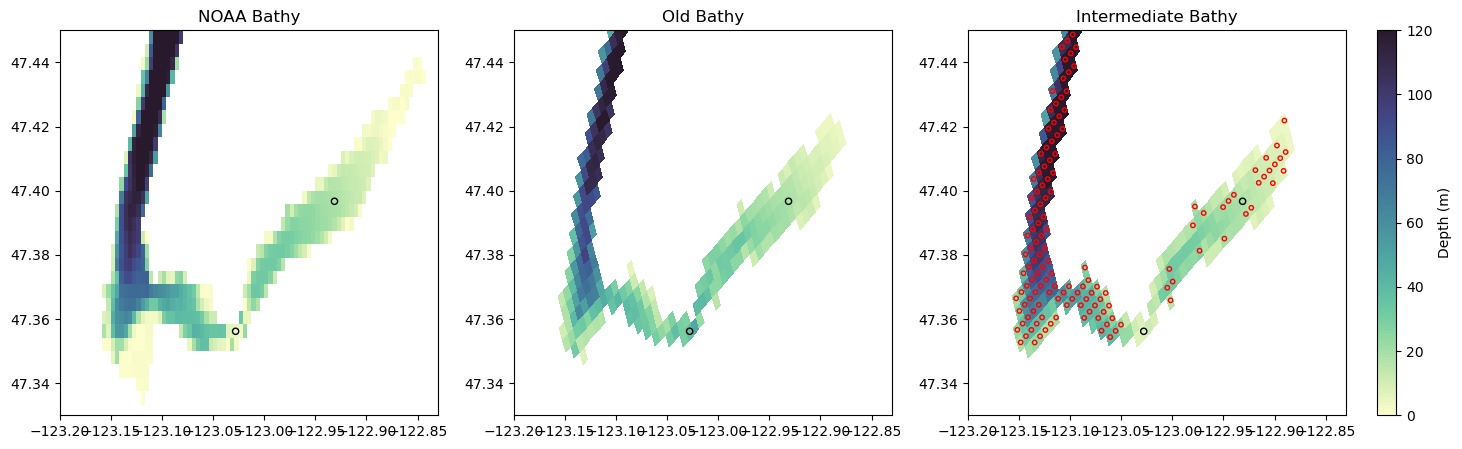

In [30]:
# Plotting
cmap_masked = cm.deep.copy()
cmap_masked.set_bad('white')

new_bathy_interp_plot = np.where(
    new_bathy_interp <= 0, np.nan, new_bathy_interp
)

intermediate_bathy_plot = intermediate_bathy.copy()
intermediate_bathy_plot[~noaa_valid & mask_LC] = np.nan

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

vmin, vmax = 0, 120

# NOAA 
m0 = ax[0].pcolormesh(
    lon_obs, lat_obs, depth_obs,
    cmap=cmap_masked, vmin=vmin, vmax=vmax,
    shading='auto'
)
ax[0].set_title("NOAA Bathy")

# original model
m2 = ax[1].pcolormesh(
    lon, lat, old_bathy,
    cmap=cmap_masked, vmin=vmin, vmax=vmax
)
ax[1].set_title("Old Bathy")

# modified model
m3 = ax[2].pcolormesh(
    lon, lat, intermediate_bathy,
     cmap=cmap_masked, vmin=vmin, vmax=vmax
)

ax[0].scatter(float(lon[j_LyC, i_LyC]), float(lat[j_LyC, i_LyC]), marker='o', facecolors='none', edgecolors='black', s=20)
ax[0].scatter(float(lon[j_Sis, i_Sis]), float(lat[j_Sis, i_Sis]), marker='o', facecolors='none', edgecolors='black', s=20)
ax[1].scatter(float(lon[j_LyC, i_LyC]), float(lat[j_LyC, i_LyC]), marker='o', facecolors='none', edgecolors='black', s=20)
ax[1].scatter(float(lon[j_Sis, i_Sis]), float(lat[j_Sis, i_Sis]), marker='o', facecolors='none', edgecolors='black', s=20)
ax[2].scatter(float(lon[j_LyC, i_LyC]), float(lat[j_LyC, i_LyC]), marker='o', facecolors='none', edgecolors='black', s=20)
ax[2].scatter(float(lon[j_Sis, i_Sis]), float(lat[j_Sis, i_Sis]), marker='o', facecolors='none', edgecolors='black', s=20)
ax[2].scatter(lon[jj, ii], lat[jj, ii], marker='o', facecolors='none', edgecolors='red', s=10, label="Deepened")

ax[2].set_title("Intermediate Bathy")

# zoom to Lynch Cove
for a in ax.flat:
    a.set_xlim(xminLC, xmaxLC)
    a.set_ylim(yminLC, ymaxLC)

# external colorbar
fig.colorbar(m3, ax=ax, location='right', pad=0.02, label='Depth (m)')

#plt.tight_layout()
plt.show()


# Write out

In [42]:
ysize = final_bathy.shape[0]; xsize = final_bathy.shape[1]
print (ysize, xsize)

898 398


In [ ]:
bathy202604 = nc.Dataset('./bathymetry_202604.nc', 'w')
bathy202604.createDimension('y', ysize)
bathy202604.createDimension('x', xsize)
nc_tools.show_dimensions(bathy202604)

"<class 'netCDF4.Dimension'>": name = 'y', size = 898
"<class 'netCDF4.Dimension'>": name = 'x', size = 398


In [109]:
newlons = bathy202604.createVariable('nav_lon', float, ('y', 'x'), zlib=True)
newlons.setncattr('units', 'degrees_east')
newlons.setncattr('long_name', 'longitude')
newlats = bathy202604.createVariable('nav_lat', float, ('y', 'x'), zlib=True)
newlats.setncattr('units', 'degrees_north')
newlats.setncattr('long_name', 'latitude')

newdepths = bathy202604.createVariable(
    'Bathymetry', float, ('y', 'x'), 
    zlib=True, least_significant_digit=0.1, fill_value=0)
newdepths.setncattr('units', 'metres')
newdepths.setncattr('long_name', 'sea_floor_depth')

newlons[:] = lon[:]
newlats[:] = lat[:]
newdepths[:] = final_bathy[:]

In [110]:
bathy202604.setncattr('title', 'Bathymetry 202604')
bathy202604.setncattr('comment', 'NOAA bathy used in South Hood Canal and Lynch Cove')
bathy202604.setncattr('references', '/ocean/atall/MOAD/analysis-abdoul/notebooks/bathy/bathymetry_202604.nc')
bathy202604.setncattr('source', '/ocean/atall/MOAD/analysis-abdoul/notebooks/bathy/bathymetry-NOAA-LynchCove.ipynb')
from datetime import datetime

bathy202604.setncattr('Conventions', 'CF-1.6')
bathy202604.setncattr('institution', 'University of British Columbia')

bathy202604.setncattr(
    'history',
    f"{datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')} UTC: "
    "Created bathymetry file using NOAA data merged into model grid in South Hood Canal andLynch Cove"
)

/tmp/ipykernel_3498147/1962138057.py:12: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  f"{datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')} UTC: "


In [111]:
nc_tools.check_dataset_attrs(bathy202604)

In [112]:
nc_tools.show_dataset_attrs(bathy202604)

file format: NETCDF4
title: Bathymetry 202604
comment: NOAA bathy used in South Hood Canal and Lynch Cove
references: /ocean/atall/MOAD/analysis-abdoul/notebooks/bathy/bathymetry_202604.nc
source: /ocean/atall/MOAD/analysis-abdoul/notebooks/bathy/bathymetry-NOAA-LynchCove.ipynb
Conventions: CF-1.6
institution: University of British Columbia
history: 2026-04-28 17:44:52 UTC: Created bathymetry file using NOAA data merged into model grid in South Hood Canal andLynch Cove


In [113]:
bathy202604.close()